In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle

import numpy as np
import scipy
import pandas as pd
from scipy.stats import pearsonr, zscore

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import r2_score

import imageio.v2 as imageio
import torch
import torch.nn.functional as F
from torchvision import transforms

from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor

from utils import align_channels_across_runs, compute_ncsnr_all_timepoints, reshape_electrode_data_by_stimuli, extract_images_with_n_repeats, ncsnr_figs
# from PSN.psn import psn

# import mne.stats

np.random.seed(42)

/gpfs/milgram/pi/turk-browne/projects/NSD_iEEG_share/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
base_dir = '/home/ri99/ieeg'
ieeg_dir = f'{base_dir}/data/subjects/111'
csv_dir = f'{base_dir}/data/nsd_PTB'
img_dir = f'{base_dir}/data/nsd_ecog'

data_dir = f'{base_dir}/data/hfb'
output_dir = f'{base_dir}/outputs/hfb'
cache_dir = f'{base_dir}/.cache'

os.makedirs(cache_dir, exist_ok=True)
sub = 11
n_blocks = -1  # -1 = use all blocks
n_runs = 56

sampling_rate = 1024  # Hz
baseline_time = 0.2  # seconds of data per trial before stimulus onset
# subject 111 had 5600 images split into 4 distinct sessions over 2 days (day 1: runs 1-12 and 13-24; day 2: runs 25-36 and 37-56)

load_from_file = True

In [4]:
curric = pd.read_csv(f"{csv_dir}/curriculum_patient{sub}.csv")
curric.head()

,Unnamed: 0,filename,inventory,coco_id,is_repeat,repetition_number,block
0,0,special_23715.png,1x-shared1000_A,23715.0,0,1,1
1,1,notspecial_24264.png,1x-shared1000_A,24264.0,0,1,1
2,2,pair_45_w_pagoda1.png,MST,NaN,0,1,1
3,3,pair_33_nsd_777_1_cocoid_68844.png,MST,68844.0,0,1,1
4,4,notspecial_36682.png,3x-shared1000_A,36682.0,0,1,1


In [5]:
if n_blocks == -1:  # use all available blocks
    block_list = curric['block'].unique().astype(str)
else:  # use n_blocks to specify instead
    block_list = [str(x) for x in range(1, n_blocks+1)]

print(block_list)
image_names = list(curric[curric['block'].isin(block_list)]['filename'])
print(len(image_names))

['1' '2' '3' '4' 'filler_block_1' 'filler_block_2']
5600


In [6]:
# load bipolar-referenced voltage trace data (no frequency decomposition) at 1024Hz
run_list = list(range(1, n_runs+1))

all_data = []
all_labels = []
time_ref = None

for run in tqdm(run_list):
    if load_from_file is False:
        data = np.load(f"{ieeg_dir}/bandpower1024/npy/sub1{sub}_NSD_run{run}_bandpower70-170.npy")
    labels = pd.read_csv(f"{ieeg_dir}/bandpower1024/ch_labels/sub1{sub}_NSD_run{run}_bandpower_channels.csv")
    time = np.load(f"{ieeg_dir}/bandpower1024/time/sub1{sub}_NSD_run{run}_bandpower_time.npy")

    if load_from_file is False:
        assert time.shape[0] == data.shape[2], f"time mismatch in run {run}"
        assert labels.shape[0] == data.shape[1], f"label mismatch in run {run}"
    
    if time_ref is None:
        time_ref = time
    else:
        assert np.allclose(time, time_ref), f"time array differs in run {run}"

    if load_from_file is False:
        all_data.append(data)
    all_labels.append(labels)

if load_from_file is False:
    print(len(all_data))

100%|██████████| 56/56 [00:00<00:00, 833.38it/s]


In [7]:
if load_from_file is False:
    # combine data across runs while dealing with some runs not having data from the same channels
    data, channel_info = align_channels_across_runs(all_data, all_labels)
    data = data.transpose(1,2,0).astype(np.float16)  # convert to channels x time x trials
    print(f"Final shape: {data.shape}")
    print(channel_info.head())
    channel_info.to_csv(f'{data_dir}/channel_info.csv', index=False)
else:
    channel_info = pd.read_csv(f'{data_dir}/channel_info.csv')

# reshape to identify repeated stimuli

In [8]:
if load_from_file is False:
    # First, reshape your electrode data using the existing function
    reshaped_electrode_data, stim_info = reshape_electrode_data_by_stimuli(
        data,  # Your electrode data (channels, time, trials)
        curric,         # Your events dataframe
        stim_column='coco_id'
    )
    np.save(f'{data_dir}/reshaped_electrode_data', reshaped_electrode_data)
    with open(f'{data_dir}/stim_info.pkl', 'wb') as f:
        pickle.dump(stim_info, f)

else:
    print('loaded reshaped_electrode_data, stim_info from file')
    reshaped_electrode_data = np.load(f'{data_dir}/reshaped_electrode_data.npy')
    with open(f'{data_dir}/stim_info.pkl', 'rb') as f:
        stim_info = pickle.load(f)

loaded reshaped_electrode_data, stim_info from file


# measure NCSNR and noise ceiling pct over time to identify electrodes with good signal 

loading processed data and ncsnr from file
NCSNR results shape: (100, 2049)
NC results shape: (100, 2049)


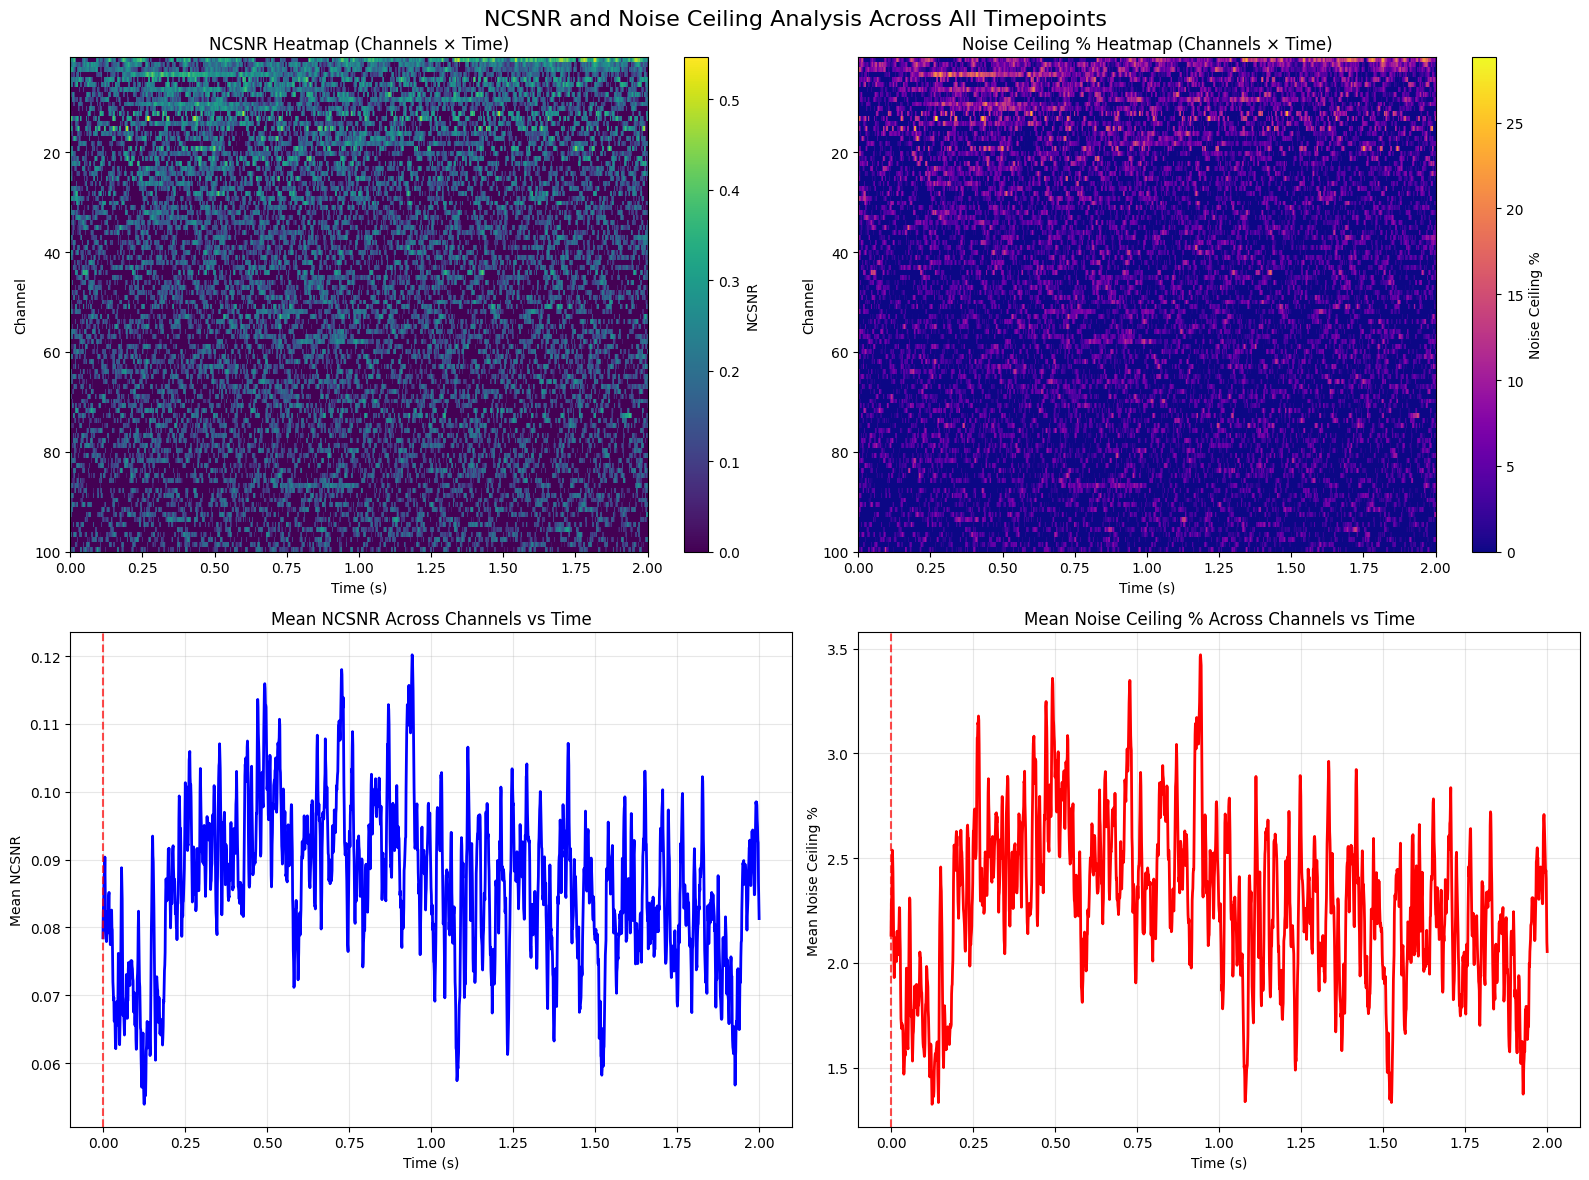


Summary Statistics:
Mean NCSNR across all channels and time: 0.086
Max NCSNR: 0.546
Mean Noise Ceiling across all channels and time: 2.3%
Max Noise Ceiling: 28.8%
Peak NCSNR time: 0.9ms
Peak NC time: 0.9ms


In [9]:
if load_from_file is False:
    data_rep = reshaped_electrode_data.transpose(1, 0, 3, 2)
    data_slim = data_rep[:,:,:]
    print(f"Transposed data shape: {data_slim.shape}")
    print(f"Shape interpretation: ({data_slim.shape[0]} conditions/images, {data_slim.shape[1]} channels, {data_slim.shape[2]} trials/repeats, {data_slim.shape[3]} timepoints)")
    np.save(f'{data_dir}/data_slim', data_slim, allow_pickle=True)
    
    # Compute NCSNR for all timepoints
    ncsnr_all, nc_all = compute_ncsnr_all_timepoints(data_slim, time)
    np.save(f'{data_dir}/ncsnr_all', ncsnr_all, allow_pickle=True)
    np.save(f'{data_dir}/nc_all', nc_all, allow_pickle=True)
else:
    print('loading processed data and ncsnr from file')
    data_slim = np.load(f'{data_dir}/data_slim.npy')
    ncsnr_all = np.load(f'{data_dir}/ncsnr_all.npy')
    nc_all = np.load(f'{data_dir}/nc_all.npy')
    
rankings = np.flip(np.argsort(ncsnr_all.mean(1)))
# Visualize the results
ncsnr_figs(ncsnr_all[rankings[:100]], nc_all[rankings[:100]], time, save_path=f'{output_dir}/ncsnr_bandpower')

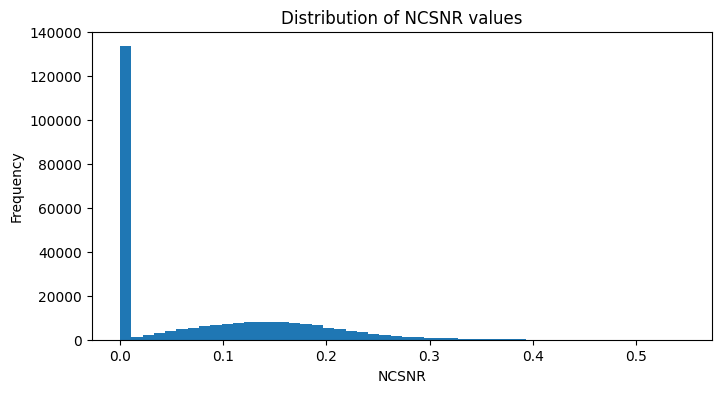

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(ncsnr_all.flatten(), bins=50)
plt.title("Distribution of NCSNR values")
plt.xlabel("NCSNR")
plt.ylabel("Frequency")
plt.show()

In [12]:
# calculate average response of each channel
print(reshaped_electrode_data.shape)

# baseline_start_idx = int(np.floor(baseline_time+0.2 * sampling_rate))  # baseline duration (sec; -0.2-0.2sec post stim onset) * sampling rate (1/sec)
# baseline_mean = np.mean(reshaped_electrode_data[:,:,:baseline_start_idx,:], axis=2)
# avg_signal = reshaped_electrode_data - baseline_mean[:,:,np.newaxis,:]  # baseline subtract per trial

avg_signal = np.nanmean(reshaped_electrode_data, axis=(3,1))  # average over repeats (dim 3) and conditions (dim 1)

print(avg_signal.shape)

(130, 2900, 2049, 4)
(130, 2049)


Plotting...


100%|██████████| 130/130 [00:08<00:00, 15.03it/s]


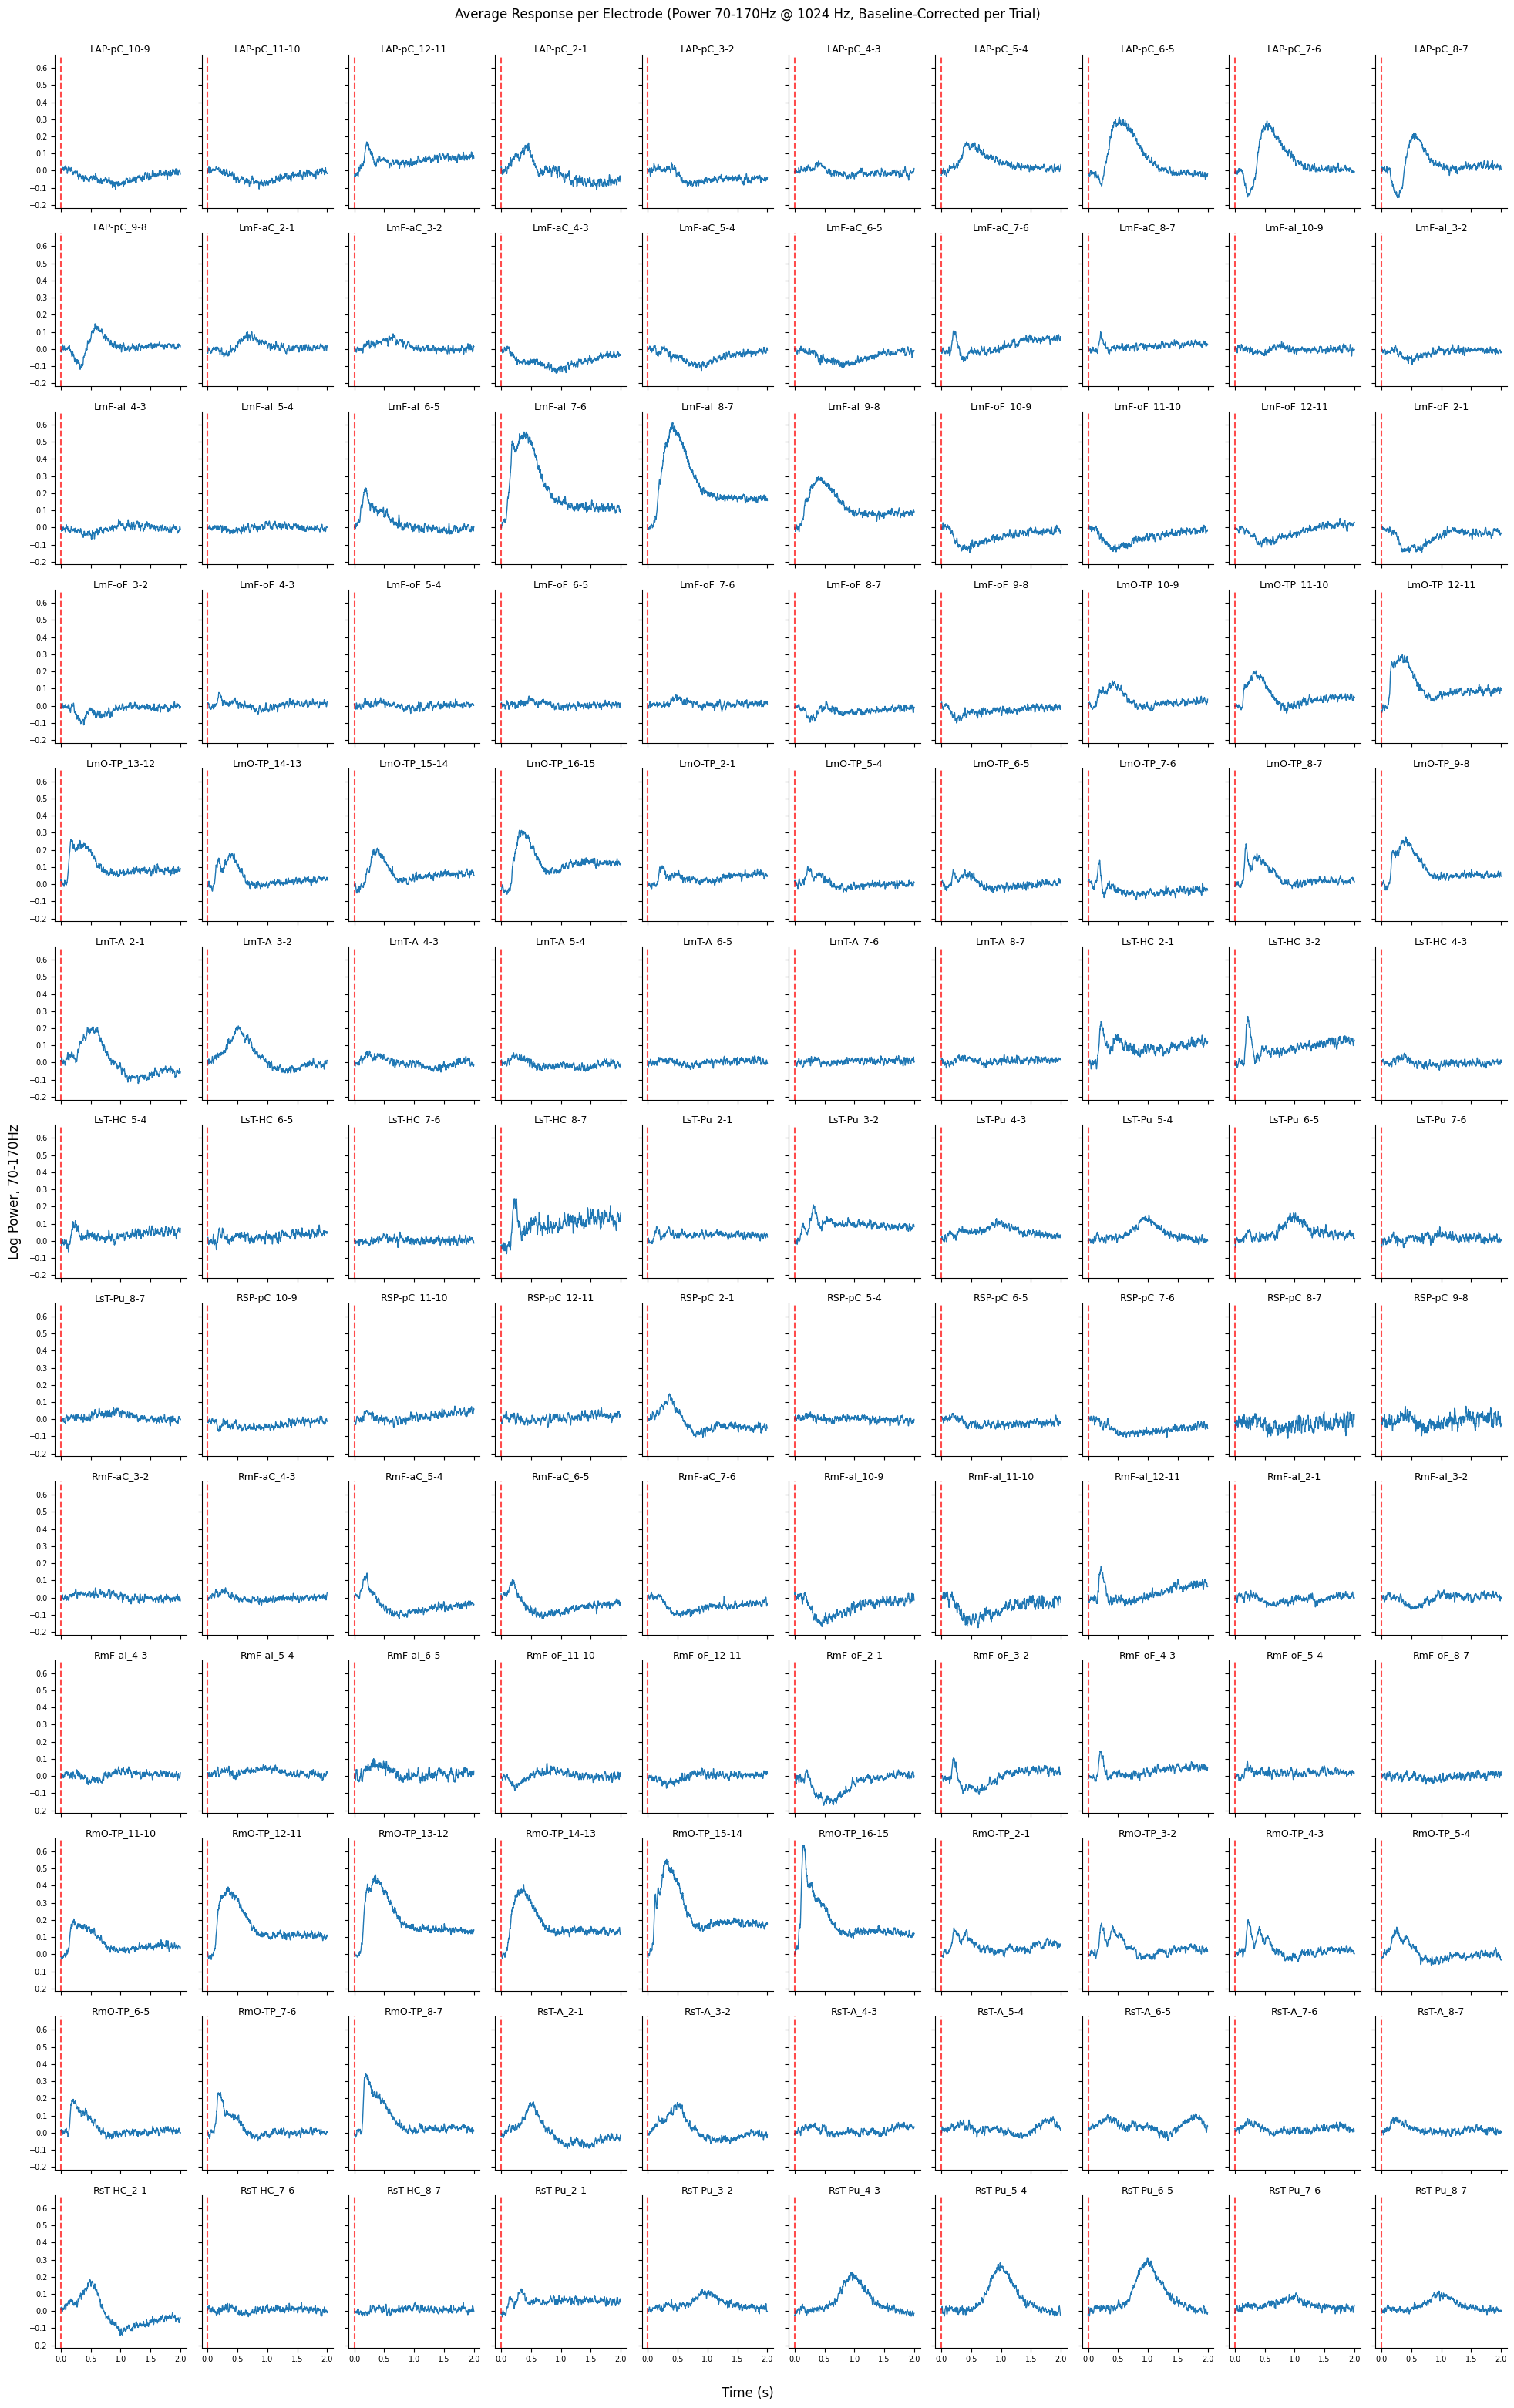

In [13]:
ncols = 10
nrows = int(np.ceil(len(avg_signal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 32), sharex=True, sharey=True)
fig.suptitle(f'Average Response per Electrode (Power 70-170Hz @ {sampling_rate} Hz, Baseline-Corrected per Trial)')
fig.supxlabel('Time (s)')
fig.supylabel('Log Power, 70-170Hz')
axes_flat = axes.flatten()

print('Plotting...')
for i in tqdm(range(len(avg_signal))):
    ax = axes_flat[i]
    ax.plot((np.arange(avg_signal.shape[1])/sampling_rate), avg_signal[i], linewidth=1)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    
    curr_label = channel_info.iloc[i]
    # if int(curr_label['channel_idx']) in rankings[:20]:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2, color='red', fontweight='bold')
    # elif int(curr_label['channel_idx']) in rankings[20:50]:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2, color='orange')
    # else:
    #     ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2)
    ax.set_title(f"{curr_label['channel_name']}", fontsize=9, pad=2)
    
    ax.tick_params(labelsize=7)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0.01, 0.01, 1, 0.98])
plt.savefig(f'{output_dir}/avg_response_bandpower')
plt.show()

In [14]:
print(avg_signal.shape)
print(reshaped_electrode_data.shape)

(130, 2049)
(130, 2900, 2049, 4)


In [15]:
# X = np.nanmean(reshaped_electrode_data, axis=3).transpose(1, 2, 0)
# X = np.nan_to_num(X, nan=0.0)
# t_obs, clusters, cluster_pv, H0 = permutation_cluster_1samp_test(X, n_jobs=-1)

In [16]:
# sig_indices = np.where(cluster_pv < 0.05)[0]

# print(f"Found {len(sig_indices)} significant clusters!")

# significant_points = np.zeros(f_obs.shape, dtype=bool)

# for i in sig_indices:
#     significant_points[clusters[i]] = True

# channels_with_sig = np.any(significant_points, axis=0)
# print(f"Channels with significant clusters: {np.where(channels_with_sig)[0]}")

# plt.figure(figsize=(10, 6))
# plt.imshow(t_obs.T, aspect='auto', origin='lower', cmap='RdBu_r')
# plt.colorbar(label='Statistic Value')

# plt.contour(significant_points.T, colors='black', levels=[0.5], linestyles='--')

# plt.xlabel('Timepoints')
# plt.ylabel('Channels')
# plt.title('Significant Clusters (p < 0.05)')
# plt.show()